In [1]:
# Import libraries required for data analysis and visualization
import pandas as pd              # for loading and manipulating datasets
import matplotlib.pyplot as plt  # for creating graphs
import seaborn as sns            # for statistical visualizations
from scipy import stats          # for statistical tests such as t-tests
import numpy as np               # for high-performance numerical computing

In [2]:
# Load the dataset containing the experiment data
df = pd.read_csv("undergraduate_project_dataset.csv")

# Display the first few rows to verify that the dataset loaded correctly
df.head()

,SN,Method,Gender,Pre-Test,Post-Test
0,1,Peer-Group,Male,29,30
1,2,Peer-Group,Female,26,26
2,3,Peer-Group,Male,10,27
3,4,Peer-Group,Male,21,28
4,5,Peer-Group,Male,11,27


In [3]:
# Check the structure of the dataset including column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   SN         100 non-null    int64 
 1   Method     100 non-null    object
 2   Gender     100 non-null    object
 3   Pre-Test   100 non-null    int64 
 4   Post-Test  100 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 4.0+ KB


In [4]:
# Create a new column 'Improvement' to measure how much each student's score increased after instruction
df["Improvement"] = df["Post-Test"] - df["Pre-Test"]

# Display the first few rows to confirm the new column was created
df.head()

,SN,Method,Gender,Pre-Test,Post-Test,Improvement
0,1,Peer-Group,Male,29,30,1
1,2,Peer-Group,Female,26,26,0
2,3,Peer-Group,Male,10,27,17
3,4,Peer-Group,Male,21,28,7
4,5,Peer-Group,Male,11,27,16


In [5]:
# Generate summary statistics only for the test score columns
df[["Pre-Test", "Post-Test"]].describe()

,Pre-Test,Post-Test
count,100.000000,100.000000
mean,14.870000,22.740000
std,8.907669,4.931081
min,1.000000,11.000000
25%,8.000000,20.000000
50%,13.000000,24.000000
75%,23.000000,26.000000
max,30.000000,31.000000


In [6]:
# Compare pre-test scores to check if groups were similar before instruction
peer_pre = df[df["Method"] == "Peer-Group"]["Pre-Test"]
lecture_pre = df[df["Method"] == "Lecture"]["Pre-Test"]

t_stat_pre, p_value_pre = stats.ttest_ind(peer_pre, lecture_pre)

print("Pre-test comparison")
print("T-statistic:", t_stat_pre)
print("P-value:", p_value_pre)

Pre-test comparison
T-statistic: 0.25698364943107604
P-value: 0.7977301654745548


In [7]:
# Calculate mean pre-test and post-test scores for each teaching method
df.groupby("Method")[["Pre-Test","Post-Test"]].mean()

,Pre-Test,Post-Test
Method,,
Lecture,14.64,21.28
Peer-Group,15.10,24.20


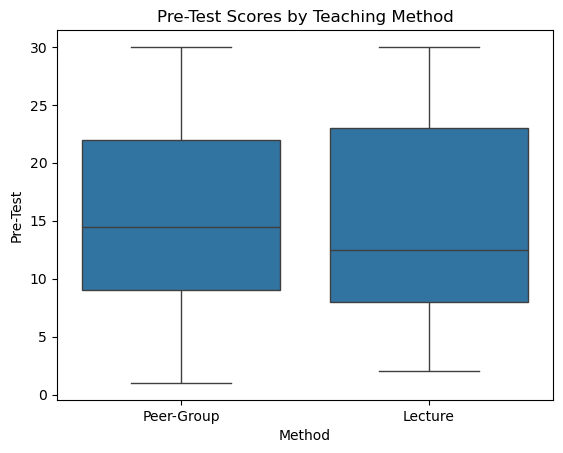

In [8]:
# Compare pre-test and post-test scores by teaching method
sns.boxplot(x="Method", y="Pre-Test", data=df)

plt.title("Pre-Test Scores by Teaching Method")
plt.savefig("pre_test_scores_by_method.png", dpi=300)  # Save as high-quality image
plt.show()

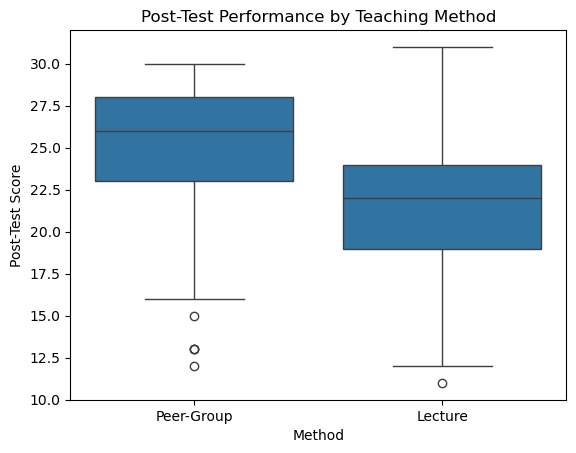

In [9]:
# Visualize post-test performance by teaching method
sns.boxplot(x="Method", y="Post-Test", data=df)

plt.title("Post-Test Performance by Teaching Method")
plt.xlabel("Method")
plt.ylabel("Post-Test Score")
plt.savefig("post_test_scores_by_method.png", dpi=300)  # Save as high-quality image
plt.show()

In [10]:
# Calculate correlation between pre-test and post-test scores
correlation, p_corr = stats.pearsonr(df["Pre-Test"], df["Post-Test"])

print("Correlation:", correlation)
print("P-value:", p_corr)

Correlation: 0.27034952189635275
P-value: 0.0065211139931965634


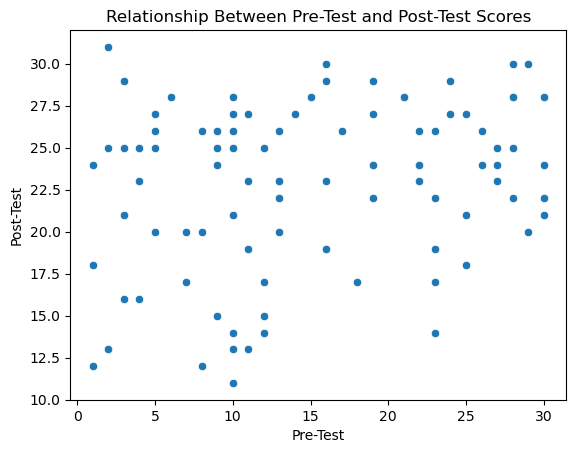

In [11]:
# Create a scatter plot to examine the relationship between students' pre-test and post-test scores
sns.scatterplot(x="Pre-Test", y="Post-Test", data=df)

plt.title("Relationship Between Pre-Test and Post-Test Scores")
plt.show()

In [12]:
# Separate the post-test scores for the two teaching methods
peer_scores = df[df["Method"] == "Peer-Group"]["Post-Test"]
lecture_scores = df[df["Method"] == "Lecture"]["Post-Test"]

# Perform an independent samples t-test
t_stat, p_value = stats.ttest_ind(peer_scores, lecture_scores)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 3.085600273112402
P-value: 0.0026406546308559535


In [13]:
# Calculate average post-test scores for male and female students
df.groupby("Gender")["Post-Test"].mean()

Gender
Female    22.660377
Male      22.829787
Name: Post-Test, dtype: float64

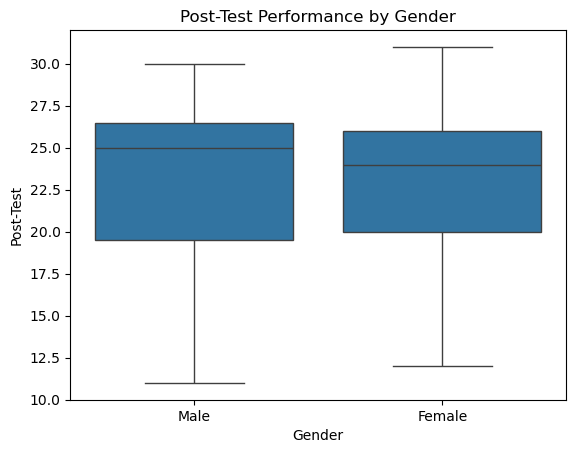

In [14]:
# Visualize post-test scores by gender
sns.boxplot(x="Gender", y="Post-Test", data=df)

plt.title("Post-Test Performance by Gender")
plt.show()

In [15]:
# Calculate the average improvement for each teaching method
df.groupby("Method")["Improvement"].mean()

Method
Lecture       6.64
Peer-Group    9.10
Name: Improvement, dtype: float64

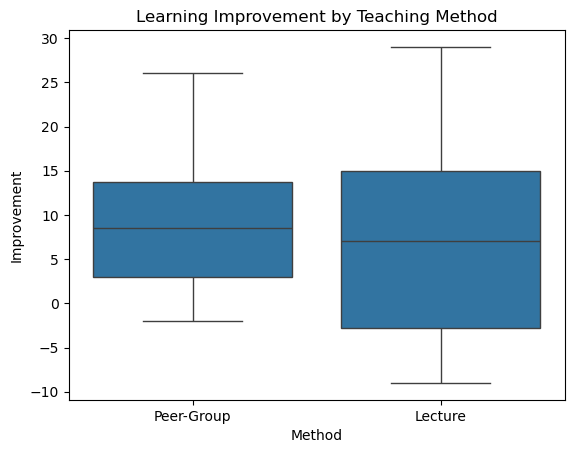

In [16]:
# Visualize improvement scores by teaching method
sns.boxplot(x="Method", y="Improvement", data=df)

plt.title("Learning Improvement by Teaching Method")
plt.xlabel("Method")
plt.ylabel("Improvement")
plt.savefig("improvement_by_method.png", dpi=300)  # Save as high-quality image
plt.show()

In [17]:
# Extract improvement scores for each teaching method
peer_improvement = df[df["Method"] == "Peer-Group"]["Improvement"]
lecture_improvement = df[df["Method"] == "Lecture"]["Improvement"]

# Perform independent samples t-test
t_stat_gain, p_value_gain = stats.ttest_ind(peer_improvement, lecture_improvement)

print("T-statistic:", t_stat_gain)
print("P-value:", p_value_gain)

T-statistic: 1.3822504149943442
P-value: 0.1700371106109827


In [18]:
# Calculate average improvement by gender
df.groupby("Gender")["Improvement"].mean()

Gender
Female    7.811321
Male      7.936170
Name: Improvement, dtype: float64

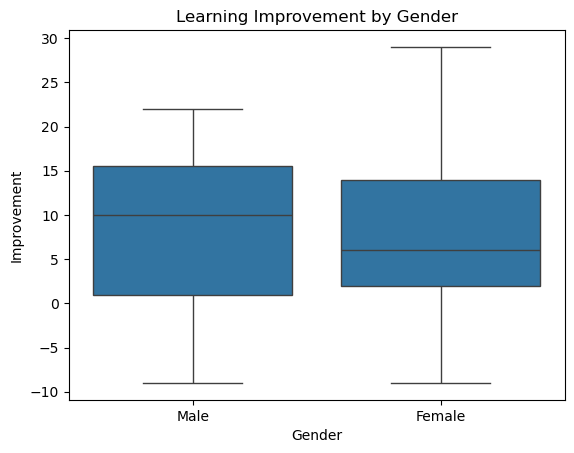

In [19]:
# Visualize improvement by gender
sns.boxplot(x="Gender", y="Improvement", data=df)

plt.title("Learning Improvement by Gender")
plt.show()

In [20]:
# Calculate Cohen's d to measure the effect size of the difference between peer-group teaching and lecture method post-test scores

# Calculate means
mean_peer = np.mean(peer_scores)
mean_lecture = np.mean(lecture_scores)

# Calculate standard deviations
std_peer = np.std(peer_scores, ddof=1)
std_lecture = np.std(lecture_scores, ddof=1)

# Sample sizes
n_peer = len(peer_scores)
n_lecture = len(lecture_scores)

# Calculate pooled standard deviation
pooled_std = np.sqrt(((n_peer - 1) * std_peer**2 + (n_lecture - 1) * std_lecture**2) / (n_peer + n_lecture - 2))

# Compute Cohen's d
cohens_d = (mean_peer - mean_lecture) / pooled_std

print("Cohen's d:", cohens_d)

Cohen's d: 0.6171200546224804
